In [1]:
#importing all required libraries

#pytorch libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

#for data handling
import numpy as np
import pandas as pd

# for visualizing
import matplotlib.pyplot as plt

#to save model weights
import pickle

In [3]:
#loading fashion MNIST csv files
train_df = pd.read_csv("Fashion Datasets/fashion-mnist_train.csv")
test_df = pd.read_csv("Fashion Datasets/fashion-mnist_test.csv")

In [4]:
#since we don't need labels for autoencoder
class FashionMNISTAutoencoder(Dataset):
    def __init__(self, dataframe):
        self.images = dataframe.iloc[:,1:].values.astype("float32") / 255.0

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image = torch.tensor(self.images[idx]).reshape(1,28,28)
        return image

In [9]:
dataset2 = FashionMNISTAutoencoder(train_df) # create dataset objects

train_size2 = int(0.8 * len(dataset2))
val_size2 = int(0.2 * len(dataset2))

train_dataset2, val_dataset2 = random_split( dataset2, [train_size2, val_size2])

#creating data loaders for batch processing
train_loader2 = DataLoader(train_dataset2, batch_size=64, shuffle=True)
val_loader2 = DataLoader(val_dataset2, batch_size=64)

epochs = 20

In [10]:
#this is autoencoder class
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        # encoder
        self.encoder = nn.Sequential(
            nn.Linear(784,128),nn.ReLU(),

            nn.Linear(128,64),nn.ReLU(),

            nn.Linear(64,32),nn.ReLU()
        )

        # decoder
        self.decoder = nn.Sequential(
            nn.Linear(32,64),nn.ReLU(),

            nn.Linear(64,128),nn.ReLU(),

            nn.Linear(128,784),

            nn.Sigmoid()# since we want output in range (0,1)
        )

    def forward(self,x):# forward propagation

        x = x.view(x.size(0),-1)

        latent = self.encoder(x) #

        reconstructed = self.decoder(latent)

        return reconstructed

In [11]:
encoder_model = AutoEncoder()

criterion2 = nn.MSELoss() # mean squared error
optimizer2 = torch.optim.Adam(encoder_model.parameters(), lr=0.001)

ae_train_losses = []
ae_val_losses = []

In [12]:
# to get the reconstructed images close to original images
for epoch in range(epochs):

    encoder_model.train() # to training mode

    running_train_loss = 0

    for images in train_loader2:

        outputs = encoder_model(images)

        loss = criterion2(outputs,images.view(images.size(0), -1))
        
        optimizer2.zero_grad()
        loss.backward()
        optimizer2.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader2)

    encoder_model.eval() # to evaluation mode

    running_val_loss = 0

    with torch.no_grad():

        for images in val_loader2:

            outputs = encoder_model(images)

            loss = criterion2(outputs,images.view(images.size(0), -1))

            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader2)

    ae_train_losses.append(train_loss)
    ae_val_losses.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}]"
        f"Training Loss: {train_loss:.6f} "
        f"Validation Loss: {val_loss:.6f}"
    )

Epoch [1/20]Training Loss: 0.040112 Validation Loss: 0.024750
Epoch [2/20]Training Loss: 0.022944 Validation Loss: 0.021684
Epoch [3/20]Training Loss: 0.020722 Validation Loss: 0.020059
Epoch [4/20]Training Loss: 0.019234 Validation Loss: 0.018769
Epoch [5/20]Training Loss: 0.018009 Validation Loss: 0.017693
Epoch [6/20]Training Loss: 0.017115 Validation Loss: 0.016946
Epoch [7/20]Training Loss: 0.016471 Validation Loss: 0.016404
Epoch [8/20]Training Loss: 0.015987 Validation Loss: 0.015908
Epoch [9/20]Training Loss: 0.015556 Validation Loss: 0.015530
Epoch [10/20]Training Loss: 0.015139 Validation Loss: 0.015138
Epoch [11/20]Training Loss: 0.014716 Validation Loss: 0.014792
Epoch [12/20]Training Loss: 0.014336 Validation Loss: 0.014327
Epoch [13/20]Training Loss: 0.014017 Validation Loss: 0.014038
Epoch [14/20]Training Loss: 0.013758 Validation Loss: 0.013809
Epoch [15/20]Training Loss: 0.013504 Validation Loss: 0.013662
Epoch [16/20]Training Loss: 0.013294 Validation Loss: 0.013454
E

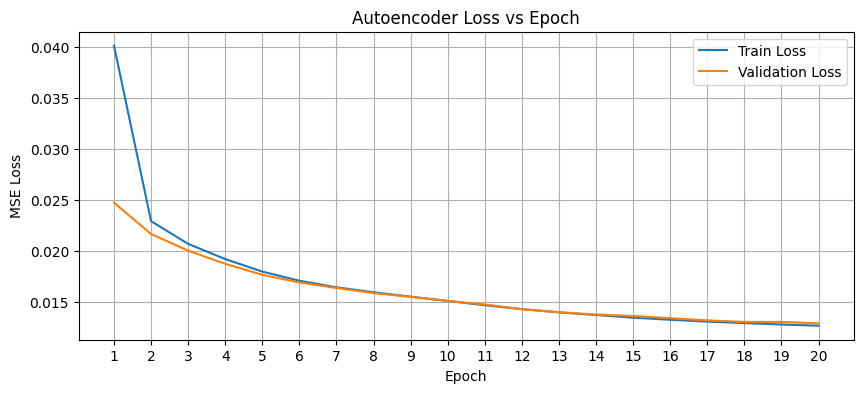

In [13]:
epoch_nums = range(1, epochs + 1)

plt.figure(figsize=(10,4))

plt.plot(epoch_nums, ae_train_losses, label="Train Loss")
plt.plot(epoch_nums, ae_val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.xticks(epoch_nums)
plt.legend()

plt.title("Autoencoder Loss vs Epoch")
plt.grid(True)

plt.show()

In [14]:
with open("best_autoencoder.pkl", "wb") as f:
    pickle.dump(encoder_model.state_dict(), f)

In [15]:
best_encoder_model = AutoEncoder()

with open("best_autoencoder.pkl", "rb") as f:
    best_encoder_model.load_state_dict(pickle.load(f))

best_encoder_model.eval()

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=784, bias=True)
    (5): Sigmoid()
  )
)

In [16]:
test_dataset2 = FashionMNISTAutoencoder(test_df)
test_loader2 = DataLoader(test_dataset2, batch_size=64, shuffle=False)

In [17]:
best_encoder_model.eval()

with torch.no_grad():

    images = next(iter(test_loader2))

    reconstructed = best_encoder_model(images)
    reconstructed = reconstructed.view(-1,1,28,28)

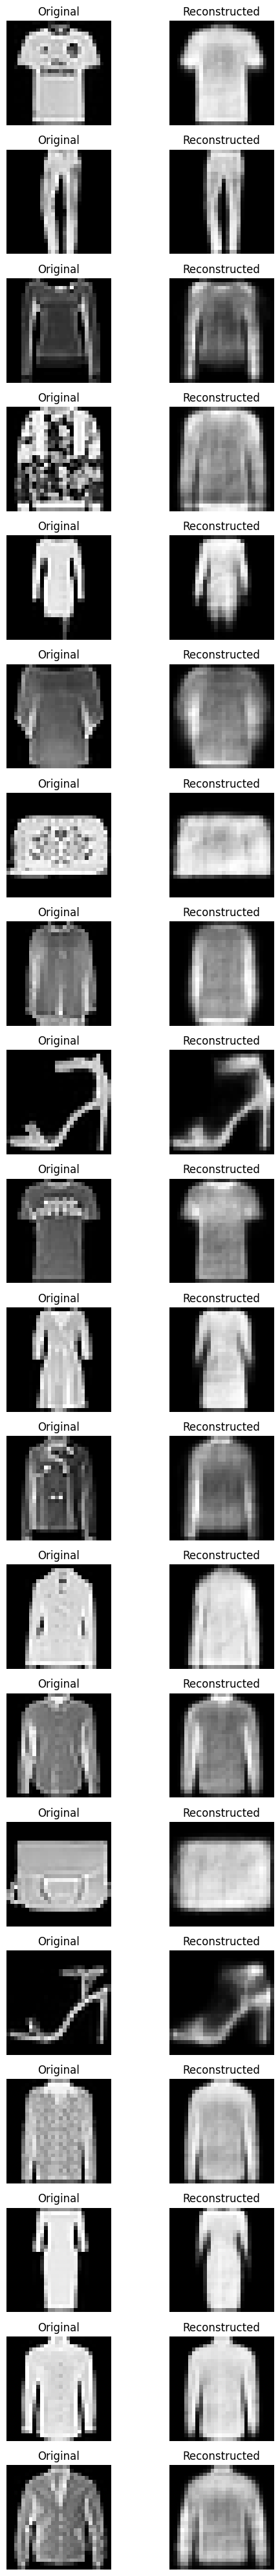

In [18]:
fig, axes = plt.subplots(20,2,figsize=(6,40))

for i in range(20):

    axes[i,0].imshow(images[i].squeeze(),cmap="gray")
    axes[i,0].set_title("Original")
    axes[i,0].axis("off")

    axes[i,1].imshow(reconstructed[i].squeeze(),cmap="gray")
    axes[i,1].set_title("Reconstructed")
    axes[i,1].axis("off")

plt.tight_layout()
plt.show()